In [1]:
PRODUCTION_QUALITY = False

import ipdb
import json
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import seaborn as sns
import pandas as pd
import os
import re
import warnings

from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings('ignore', category=MatplotlibDeprecationWarning)

plt.style.use(['science', 'bright'])

dpi = 300 if PRODUCTION_QUALITY else 100

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 12,
    'font.family': 'lmodern',
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',
    'figure.constrained_layout.use': True,
    'legend.frameon': True,
    'savefig.dpi': dpi,
})

# width of the thesis in points
#OUTPUT_DIR='../01-film-vs-lora-evaluation/images'
#WIDTH = 441.01775

# Beamer 16:9
OUTPUT_DIR='/home/arehn/presentations/meeting-20241201/images/'
WIDTH=455.24408

os.makedirs(OUTPUT_DIR, exist_ok=True) # make sure it exists

# image saving format
IMG_FORMAT = 'pdf'

In [2]:
def set_size(width_pt, fraction=1, subplots=(1, 1), y_scale=False):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])
    
    if y_scale:
        fig_height_in = fig_height_in * y_scale

    return (fig_width_in, fig_height_in)

In [3]:
def get_figure(subplots, fraction=1.0, y_scale=False):
    figsize = set_size(WIDTH, fraction=fraction, subplots=subplots, y_scale=y_scale)
    fig, axes = plt.subplots(subplots[0], subplots[1], figsize=figsize, constrained_layout=True)

    return fig, axes

In [4]:
def read_json_data(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

In [5]:
def prepare_data(data):
    records = []
    for experiment_id, experiment_details in data.items():
        # Extracting values from the JSON structure
        subset_size = experiment_details['configuration']['subset_size']
        batch_size = experiment_details['hyperparameters']['batch_size']
        learning_rate = experiment_details['best_params']['learning_rate']
        max_grad_norm = experiment_details['best_params']['max_grad_norm']
        epochs = experiment_details['best_params']['epochs']
        peft = experiment_details['configuration']['peft']
        n_trials = experiment_details['configuration']['n_trials']

        record = {
            'model_name': experiment_details['configuration']['model_name'],
            'dataset_name': experiment_details['configuration']['dataset_name'],
            'subset_size': subset_size,
            'epsilon': experiment_details['hyperparameters']['target_epsilon'],
            'batch_size': batch_size,
            'accuracy': float(experiment_details['best_value']),
            'learning_rate': learning_rate,
            'max_grad_norm': max_grad_norm,
            'epochs': epochs,
            'peft': peft,
            'n_trials': n_trials,
        }
        records.append(record)

    return pd.DataFrame(records)

In [6]:
# Mapping of full model names to abbreviations
model_name_map = {
    'vit_base_patch16_224.augreg_in21k': 'ViT',
    'resnetv2_50x1_bit.goog_in21k': 'ResNetV2',
}

# Accuracy comparison

In [7]:
def plot_accuracy_trends(prepared_data, output_dir=None):
    # Ensure data is sorted for consistent color mapping
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'peft'], inplace=True)

    # Get unique combinations of model, dataset, and subset size
    groups = prepared_data.groupby(['model_name', 'dataset_name', 'subset_size'])

    for (model, dataset, subset), group in groups:
        fig, ax = get_figure((1, 1))

        # Plotting for each PEFT method within the group
        grouped_by_peft = group.groupby('peft')
        for peft_method, peft_data in grouped_by_peft:
            peft_data = peft_data.sort_values(by='epsilon')
            ax.plot(peft_data['epsilon'], peft_data['accuracy'], label=f'PEFT: {peft_method}', marker='o')
        
        ax.set_title(f'Accuracy Trends for {model} on {dataset} ({int(subset*100)}\% Subset)')
        ax.set_xlabel('Epsilon')
        ax.set_ylabel('Accuracy')
        ax.set_ylim([0, 1])
        ax.set_xscale('log')

        unique_epsilons = np.unique(group['epsilon'])
        ax.set_xticks(unique_epsilons)
        ax.set_xticklabels(unique_epsilons, rotation=45)

        ax.legend()
        ax.grid(True)

        plt.show()


In [8]:
def plot_accuracy_trends(prepared_data, output_dir=None):
    # Ensure data is sorted for consistent color mapping
    prepared_data.sort_values(['dataset_name', 'subset_size', 'model_name', 'peft', 'epsilon'], inplace=True)

    # Get unique combinations of dataset and subset size
    dataset_subset_groups = prepared_data.groupby(['dataset_name', 'subset_size'])

    for (dataset, subset), ds_subset_group in dataset_subset_groups:
        fig, ax = get_figure((1, 1))

        # Plotting for each model and PEFT method within the dataset-subset group
        model_peft_groups = ds_subset_group.groupby(['model_name', 'peft'])
        for (model, peft_method), model_peft_group in model_peft_groups:
            model_peft_group = model_peft_group.sort_values(by='epsilon')
            ax.plot(model_peft_group['epsilon'], model_peft_group['accuracy'], label=f'{model}, PEFT: {peft_method}', marker='o')
        
        ax.set_title(f'FiLM vs LoRA Accuracy Trends for Dataset: {dataset}, Subset: {int(subset*100)}\%')
        ax.set_xlabel('Epsilon')
        ax.set_ylabel('Accuracy')
        ax.set_ylim([0, 1])
        ax.set_xscale('log')  # Log scale for x-axis

        unique_epsilons = np.unique(ds_subset_group['epsilon'])
        ax.set_xticks(unique_epsilons)
        ax.set_xticklabels(unique_epsilons, rotation=45)

        ax.legend()
        ax.grid(True)

        # Save plot if output_dir is provided
        if output_dir:
            plt.savefig(os.path.join(output_dir, f'film_vs_lora_accuracy_trends_{dataset}_subset{int(subset*100)}.pdf'))

        plt.show()


In [9]:
def plot():
    file_path = '../01-film-vs-lora-evaluation/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    plot_accuracy_trends(processed_data, output_dir=OUTPUT_DIR)

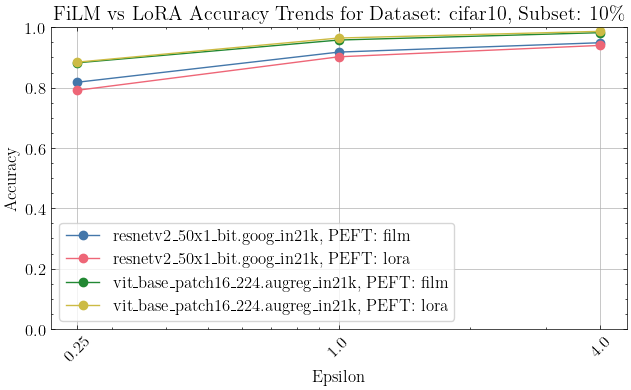

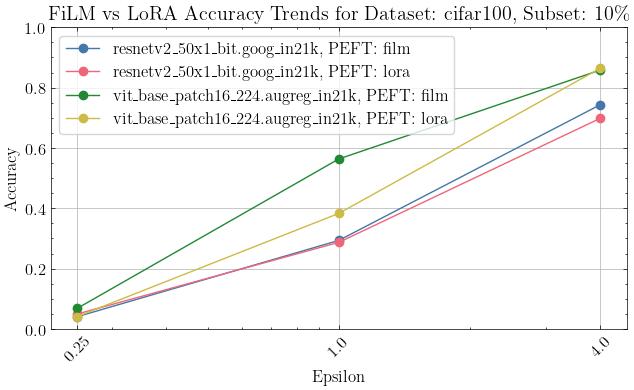

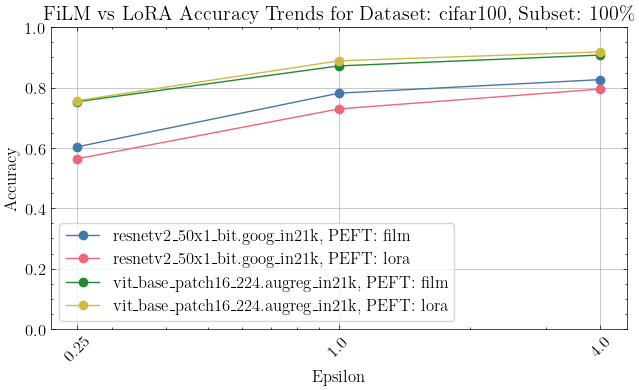

In [10]:
plot()

# 20 Trials vs 50 Trials, 10% subset

In [11]:
# def plot_dataset_accuracy_trends(prepared_data, output_dir=None):
#     # Filter out entries for cifar100 with 100% subset
#     prepared_data = prepared_data[~((prepared_data['dataset_name'] == 'cifar100') & (prepared_data['subset_size'] == 1.0))]

#     # Define visual distinctions for different n_trials
#     visuals = {20: {'line_style': '-', 'marker': 'o'}, 50: {'line_style': '--', 'marker': 's'}}

#     # Group by dataset
#     dataset_groups = prepared_data.groupby('dataset_name')

#     for dataset, dataset_group in dataset_groups:
#         fig, ax = get_figure((1, 1))

#         # Create a dictionary to store colors for each model-PEFT pair
#         color_dict = {}

#         # Iterate over each combination of model, PEFT, and n_trials within the dataset
#         model_peft_trial_groups = dataset_group.groupby(['model_name', 'peft', 'n_trials'])

#         for (model, peft_method, n_trials), model_peft_trial_group in model_peft_trial_groups:
#             visual = visuals[n_trials]

#             # Sort by epsilon before plotting
#             model_peft_trial_group_sorted = model_peft_trial_group.sort_values(by='epsilon')

#             model_name = model_name_map[model]
#             ax.plot(model_peft_trial_group_sorted['epsilon'], model_peft_trial_group_sorted['accuracy'], 
#                     label=f'{model_name}, {peft_method}, Trials={n_trials}', 
#                     linestyle=visual['line_style'], marker=visual['marker'])

#         ax.set_title(f'20 vs 50 Trials Accuracy Trends for Dataset: {dataset} (10\% Subset)')
#         ax.set_xlabel('Epsilon')
#         ax.set_ylabel('Accuracy')
#         ax.set_ylim([0, 1])
#         ax.set_xscale('log')  # Log scale for epsilon

#         unique_epsilons = np.unique(dataset_group['epsilon'])
#         ax.set_xticks(unique_epsilons)
#         ax.set_xticklabels(unique_epsilons, rotation=45)

#         ax.legend(fontsize='small')
            
#         ax.grid(True)

#         if output_dir:
#             plt.savefig(os.path.join(output_dir, f'20_vs_50trials_accuracy_trends_{dataset}.pdf'))
    
#         plt.show()

In [12]:
def plot_dataset_accuracy_trends(prepared_data, output_dir=None):
    # Filter out entries for cifar100 with 100% subset
    prepared_data = prepared_data[~((prepared_data['dataset_name'] == 'cifar100') & (prepared_data['subset_size'] == 1.0))]

    # Define visual distinctions for different n_trials
    visuals = {20: {'line_style': '-', 'marker': 'o'}, 50: {'line_style': '--', 'marker': 's'}}

    # Group by dataset
    dataset_groups = prepared_data.groupby('dataset_name')

    for dataset, dataset_group in dataset_groups:
        fig, ax = get_figure((1, 1))

        # Create a dictionary to store colors for each model-PEFT pair
        color_dict = {}

        # Iterate over each combination of model, PEFT, and n_trials within the dataset
        model_peft_trial_groups = dataset_group.groupby(['model_name', 'peft'])

        for (model, peft_method), model_peft_group in model_peft_trial_groups:
            # Get a consistent color for the model-PEFT pair
            if (model, peft_method) not in color_dict:
                color_dict[(model, peft_method)] = next(ax._get_lines.prop_cycler)['color']

            # Iterate over each n_trials within the model-peft group
            for n_trials, n_trial_group in model_peft_group.groupby('n_trials'):
                visual = visuals[n_trials]

                # Sort by epsilon before plotting
                n_trial_group_sorted = n_trial_group.sort_values(by='epsilon')

                model_name = model_name_map.get(model, model)  # Use the model name map or default to the model name
                ax.plot(n_trial_group_sorted['epsilon'], n_trial_group_sorted['accuracy'], 
                        label=f'{model_name}, {peft_method}, Trials={n_trials}', 
                        linestyle=visual['line_style'], marker=visual['marker'],
                        color=color_dict[(model, peft_method)])  # Use the stored color

        ax.set_title(f'20 vs 50 Trials Accuracy Trends for Dataset: {dataset} (10\% Subset)')
        ax.set_xlabel('Epsilon')
        ax.set_ylabel('Accuracy')
        ax.set_ylim([0, 1])
        ax.set_xscale('log')  # Log scale for epsilon

        unique_epsilons = np.unique(dataset_group['epsilon'])
        ax.set_xticks(unique_epsilons)
        ax.set_xticklabels(unique_epsilons, rotation=45)

        ax.legend(fontsize='small')
            
        ax.grid(True)

        if output_dir:
            plt.savefig(os.path.join(output_dir, f'20_vs_50trials_accuracy_trends_{dataset}.pdf'))
    
        plt.show()

In [13]:
def plot():
    file_path = '../01-film-vs-lora-evaluation/processed-data/combined_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    plot_dataset_accuracy_trends(processed_data, output_dir=OUTPUT_DIR)

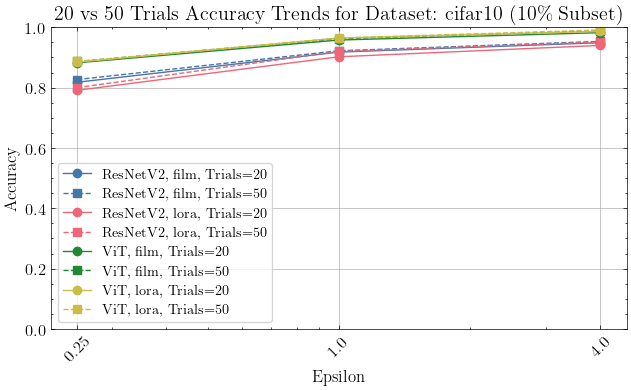

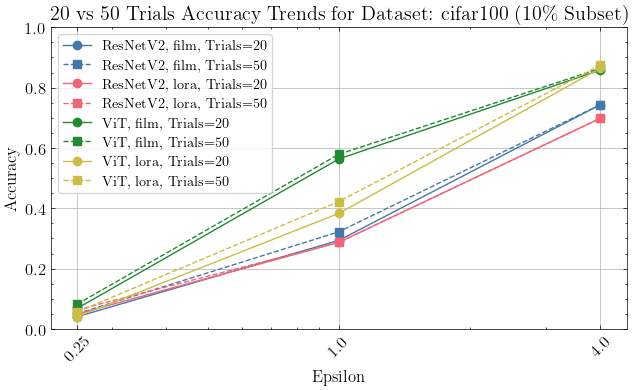

In [14]:
plot()

# Hyperparameter comparison for cifar100 10% subset vs cifar100 100% subset

In [15]:
def prepare_hyperparameters_data(data):
    rows = []
    for experiment_name, details in data.items():
        model_name = details['configuration']['model_name']
        peft = details['configuration']['peft']
        subset_size = details['configuration']['subset_size']
        dataset = details['configuration']['dataset_name']
        best_params = details['best_params']
        epsilon = details['hyperparameters']['target_epsilon']

        if dataset != 'cifar100':
            continue

        row = {
            'experiment_name': experiment_name,
            'model_name': model_name,
            'peft': peft,
            'subset_size': subset_size,
            'dataset': dataset,
            'epsilon': epsilon,
            **best_params
        }
        rows.append(row)

    return pd.DataFrame(rows)

def plot_hyperparameters_trends(df, hyperparameter, output_dir=None):
    # Calculate the max value for each epsilon group
    max_value = df[hyperparameter].max()

    for (epsilon, peft), group in df.groupby(['epsilon', 'peft']):
        fig, ax = plt.subplots(figsize=(3, 3))

        for model in group['model_name'].unique():
            model_group = group[group['model_name'] == model]

            # Extract data for 10% and 100% subsets
            data_10 = model_group[model_group['subset_size'] == 0.1]
            data_100 = model_group[model_group['subset_size'] == 1.0]

            if not data_10.empty and not data_100.empty:
                # Plotting the two points and connecting them
                ax.plot([0.1, 1.0], [data_10[hyperparameter].values[0], data_100[hyperparameter].values[0]], 
                        marker='o', linestyle='-', label=model)

        formatted_hyperparameter = hyperparameter.replace('_', ' ')
        ax.set_title(f'{formatted_hyperparameter} - Epsilon: {epsilon}, PEFT: {peft}')
        ax.set_ylabel(formatted_hyperparameter)
        ax.set_xlabel('Subset Size')
        ax.set_xticks([0.1, 1.0])
        ax.set_xticklabels(['10%', '100%'])
        ax.set_ylim(0, max_value+0.1*max_value)
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

        if output_dir:
            filename = f'hyper_transfer_10%_to_100%_{formatted_hyperparameter}_{peft}_plot.png'
            fig.savefig(os.path.join(output_dir, filename))

        plt.show()

In [16]:
def plot():
    file_path = '../01-film-vs-lora-evaluation/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    df = prepare_hyperparameters_data(data)
    for hyperparameter in ['epochs', 'batch_size', 'learning_rate', 'max_grad_norm']:
        # Define the number of rows and columns for subplots
        plot_hyperparameters_trends(df, hyperparameter, output_dir=OUTPUT_DIR)

/tmp/ipykernel_290348/2209505597.py:57: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.savefig(os.path.join(output_dir, filename))
/home/arehn/miniconda3/envs/dp/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


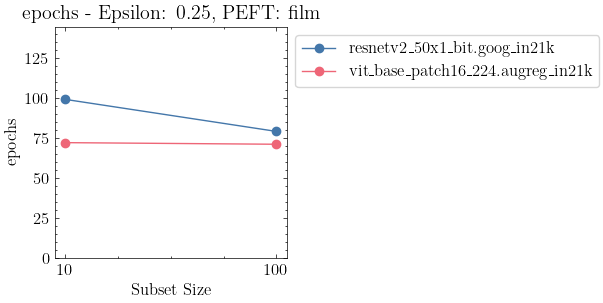

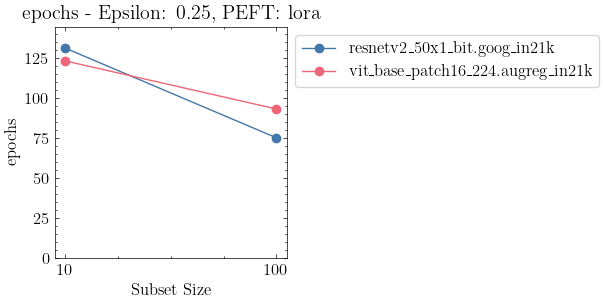

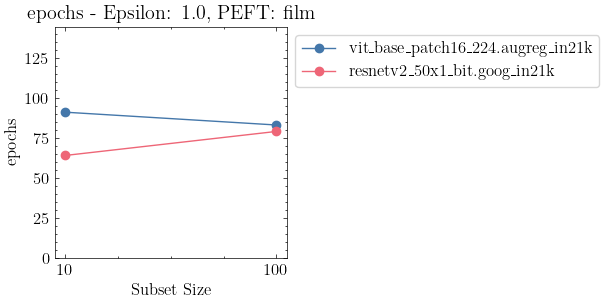

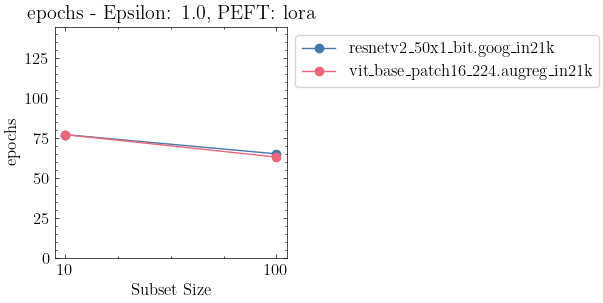

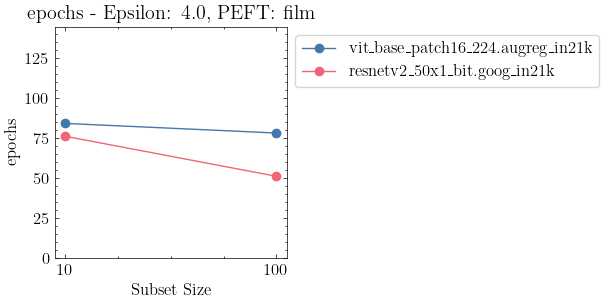

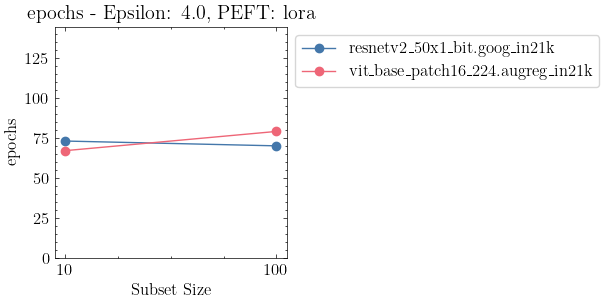

/tmp/ipykernel_290348/2209505597.py:57: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.savefig(os.path.join(output_dir, filename))
/home/arehn/miniconda3/envs/dp/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


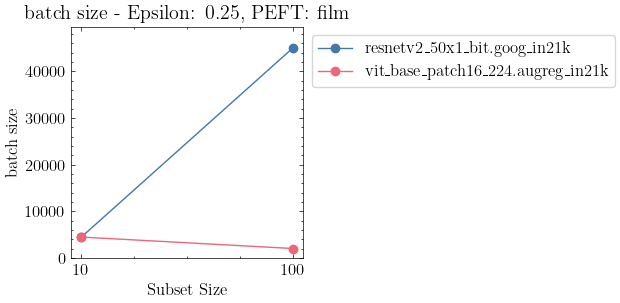

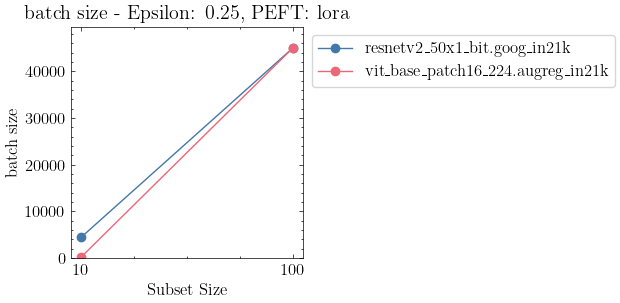

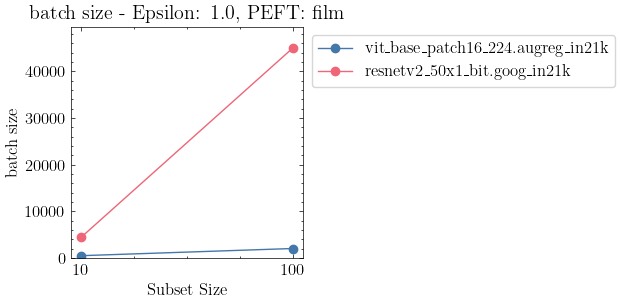

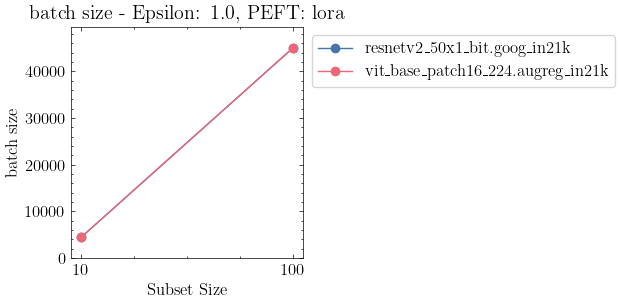

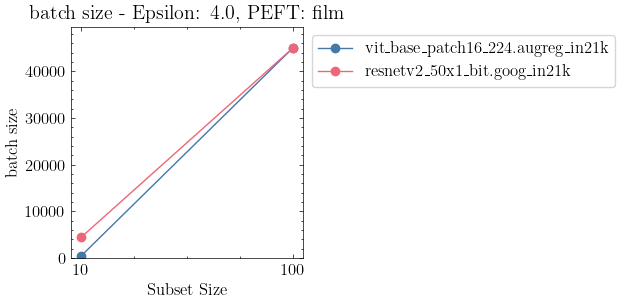

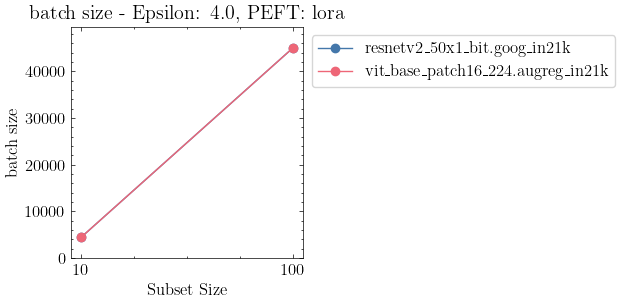

/tmp/ipykernel_290348/2209505597.py:57: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.savefig(os.path.join(output_dir, filename))
/home/arehn/miniconda3/envs/dp/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


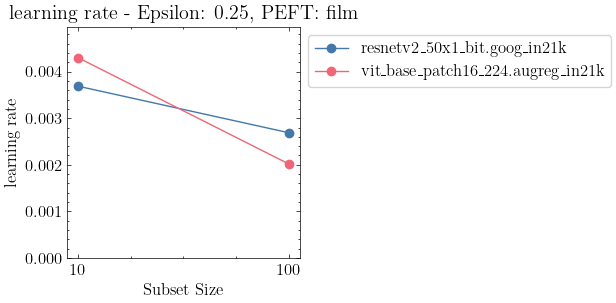

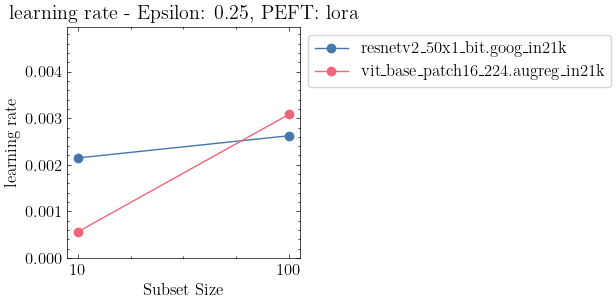

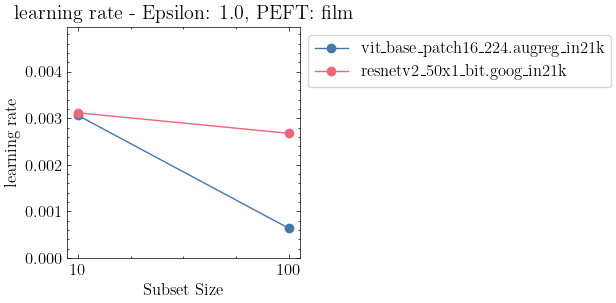

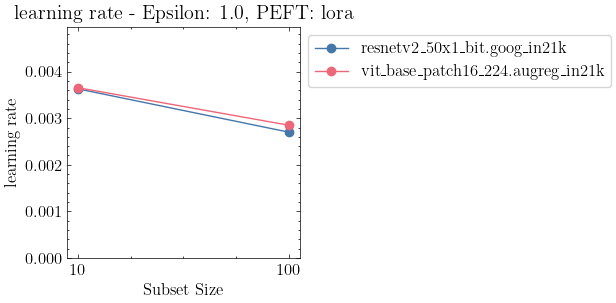

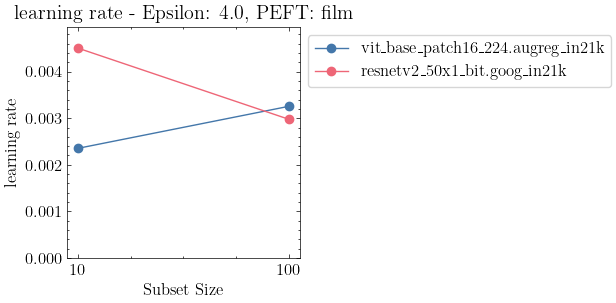

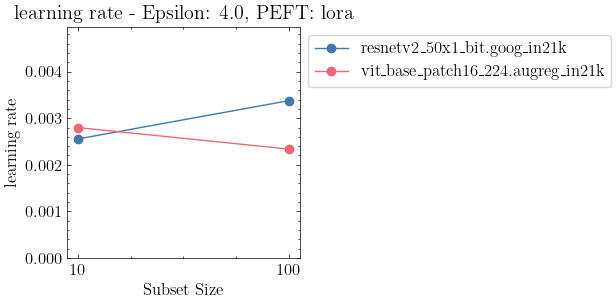

/tmp/ipykernel_290348/2209505597.py:57: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.savefig(os.path.join(output_dir, filename))
/home/arehn/miniconda3/envs/dp/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


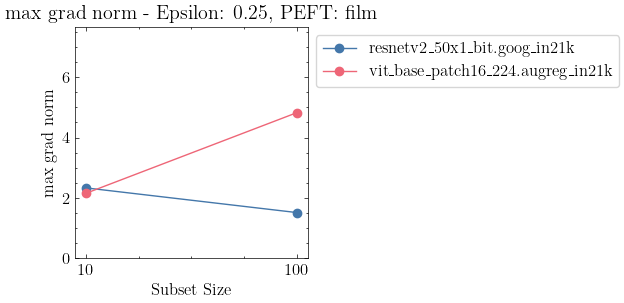

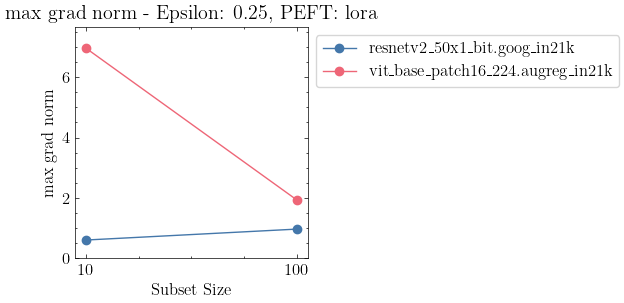

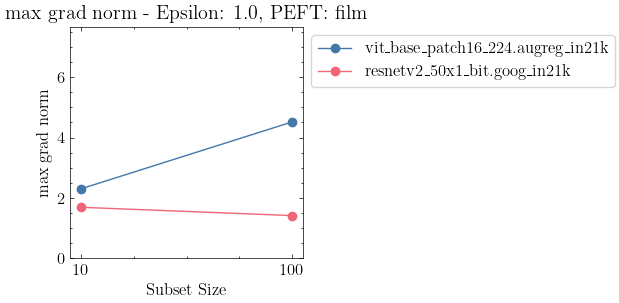

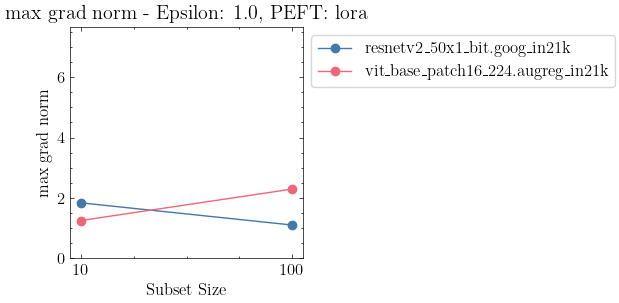

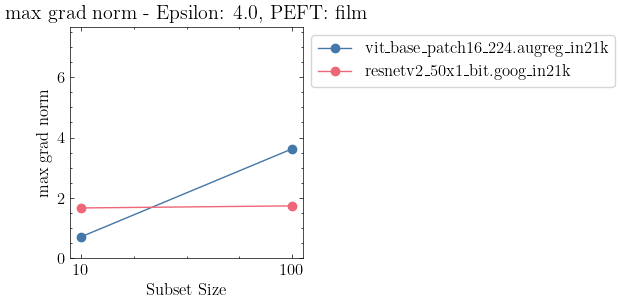

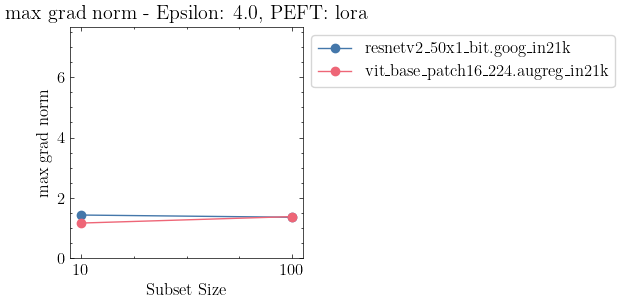

In [17]:
plot()

# Accuracy comparison Full batch vs Optimized batch

In [18]:
def prepare_accuracy_data(data, target_dataset):
    results = {}
    for key, value in data.items():
        dataset_name = value['configuration']['dataset_name']
        subset_size = value['configuration']['subset_size']
        if dataset_name == target_dataset:
            model_name = value['configuration']['model_name']
            peft_method = value['configuration']['peft'].capitalize()
            epsilon = value['hyperparameters']['target_epsilon']
            accuracy = float(value['best_value'])

            if subset_size != 0.1:
                continue

            is_full_batch = 'FullBatch' in key

            subset_key = f'{dataset_name} {subset_size*100:.0f}%'

            if subset_key not in results:
                results[subset_key] = {}
            if model_name not in results[subset_key]:
                results[subset_key][model_name] = {}
            if peft_method not in results[subset_key][model_name]:
                results[subset_key][model_name][peft_method] = {'optimized': {}, 'full_batch': {}}
            batch_type = 'full_batch' if is_full_batch else 'optimized'
            results[subset_key][model_name][peft_method][batch_type][epsilon] = accuracy

    return results

def plot_accuracy(processed_data, dataset_name, output_dir=None):
    num_subsets = len(processed_data)
    fig, axs = plt.subplots(num_subsets, 1, figsize=(10, num_subsets * 5))
    if num_subsets == 1:
        axs = [axs]

    for ax, (subset, models_data) in zip(axs, processed_data.items()):
        epsilons = sorted({ep for model_data in models_data.values() for method_data in model_data.values() for batch_type in method_data.values() for ep in batch_type.keys()})
        pos = list(range(len(epsilons)))
        bar_width = 0.2

        for idx, (model, methods_data) in enumerate(models_data.items()):
            for jdx, (peft_method, batch_data) in enumerate(methods_data.items()):
                # Extract optimized and full batch scores
                optimized_scores = [batch_data['optimized'].get(ep, 0) for ep in epsilons]
                full_batch_scores = [batch_data['full_batch'].get(ep, 0) for ep in epsilons]
                
                # Plot optimized scores
                ax.bar([p + bar_width * (idx * len(methods_data) + jdx) for p in pos], optimized_scores, width=bar_width/2, label=f'{model} - {peft_method} (Optimized)')

                # Plot full batch scores
                ax.bar([p + bar_width * (idx * len(methods_data) + jdx) + bar_width/2 for p in pos], full_batch_scores, width=bar_width/2, label=f'{model} - {peft_method} (Full Batch)')

        ax.set_ylabel('Accuracy')
        ax.set_title(f'Full batch vs optimized accuracy by Model, PEFT Method, and Epsilon ({subset})')
        ax.set_xticks([p + bar_width for p in pos])
        ax.set_xticklabels(epsilons)
        ax.set_ylim([0, 1])
        ax.legend(loc='upper left', bbox_to_anchor=(1, 0.5))

        if output_dir:
            subset_str = subset.replace(' ', '_')
            filename = f'accuracy_fullbatch_vs_optimized_by_model_peft_and_epsilon_{subset_str}_plot.png'
            plt.savefig(os.path.join(output_dir, filename))

    plt.tight_layout()
    plt.show()

In [19]:
def plot():
    file_path = '../01-film-vs-lora-evaluation/processed-data/combined_data.json'
    data = read_json_data(file_path)
    for dataset in ['cifar10', 'cifar100']:
        processed_data = prepare_accuracy_data(data, dataset)
        plot_accuracy(processed_data, dataset, output_dir=OUTPUT_DIR)

/tmp/ipykernel_290348/2662017155.py:65: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


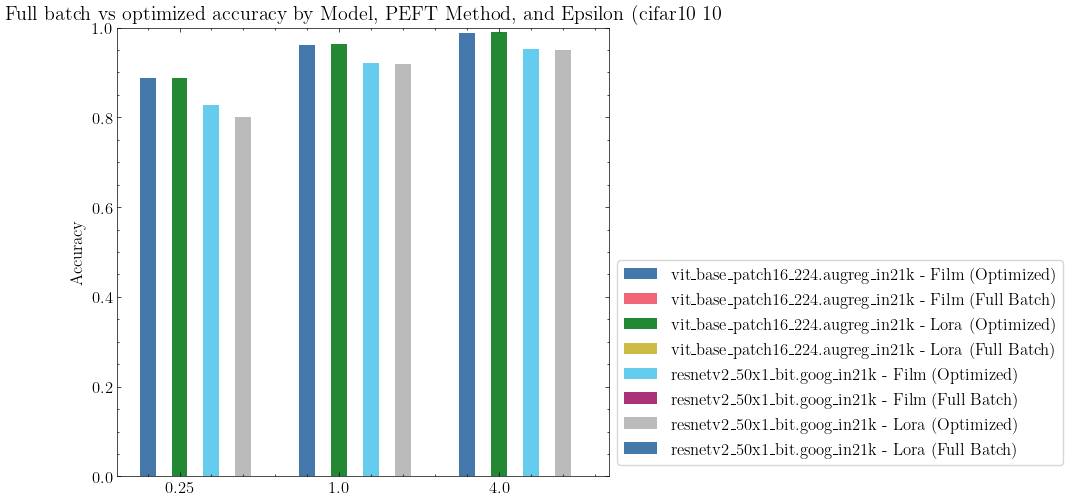

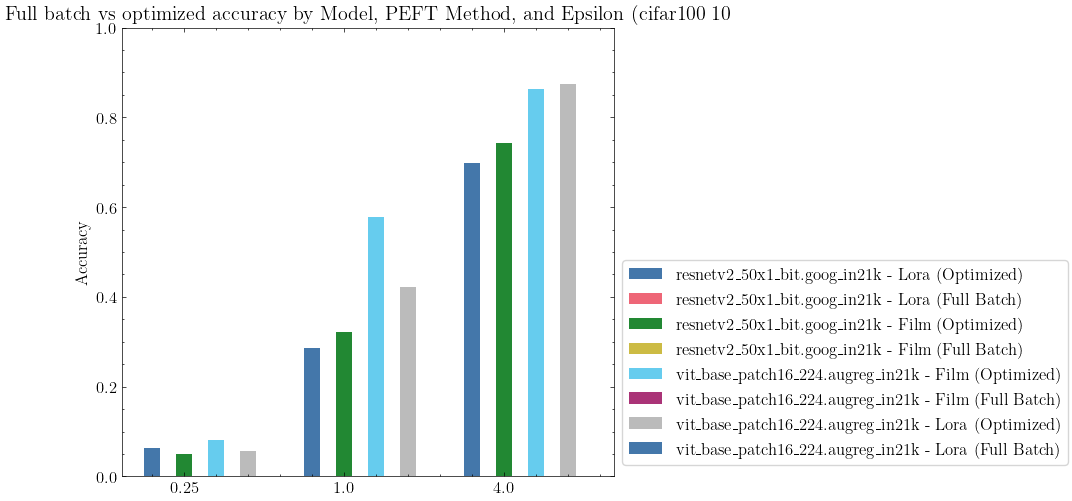

In [20]:
plot()